**Prompt I used to generate this notebook**

I want an exploratory data analysis notebook called 01-diabetes-eda placed in the folder 07-imbda-ai analysing the diabetes  130 from openml. You can load it with fetch_openml, the id number is 296.

# EDA: Diabetes 130-US hospitals

Code repository for the book:

[Imbalanced Data: Myths, Mistakes and Modern Solutions](https://www.trainindata.com/p/imbalanced-data-myths-mistakes-solutions-book)

Dataset of 10 years of clinical care at 130 US hospitals, one row per inpatient encounter of a diabetic patient. The target, `readmitted`, records whether the patient was readmitted within 30 days, after 30 days, or not at all.

Note: the id `296` I was given for `fetch_openml` is actually the UCI ML Repository id for this dataset, not its OpenML id. On OpenML this dataset is `Diabetes130US`, `data_id=4541`. I load it with that id below.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_engine.variable_handling import find_categorical_variables
from feature_engine.selection import DropConstantFeatures

from sklearn.datasets import fetch_openml

## Load data

In [2]:
data = fetch_openml(data_id=4541, as_frame=True)

X = data.data.copy()
y = data.target.copy()

X.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,Yes
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,Steady,No,No,No,No,No,Ch,Yes


## Dataset size

In [3]:
X.shape

(101766, 49)

## Variable types

In [4]:
X.dtypes

encounter_id                   int64
patient_nbr                    int64
race                        category
gender                      category
age                         category
weight                      category
admission_type_id              int64
discharge_disposition_id       int64
admission_source_id            int64
time_in_hospital               int64
payer_code                  category
medical_specialty           category
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                      category
diag_2                      category
diag_3                      category
number_diagnoses               int64
max_glu_serum               category
A1Cresult                   category
metformin                   category
repaglinide                 category
nateglinide                 category
c

In [5]:
cat_vars = find_categorical_variables(X)
len(cat_vars), X.shape[1]

(36, 49)

36 of the 49 variables are categorical. `encounter_id` and `patient_nbr` are identifiers rather than features.

## Missing data

`X.isnull()` won't find the missing values here — this dataset encodes them as the string `"?"` instead of `NaN`.

In [6]:
X.isnull().sum().sum()

np.int64(0)

In [7]:
X_na = X.copy()
for col in cat_vars:
    X_na[col] = X_na[col].astype(object).replace('?', np.nan)

X_na.isnull().mean().sort_values(ascending=False).head(10)

weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
encounter_id         0.000000
troglitazone         0.000000
glipizide            0.000000
dtype: float64

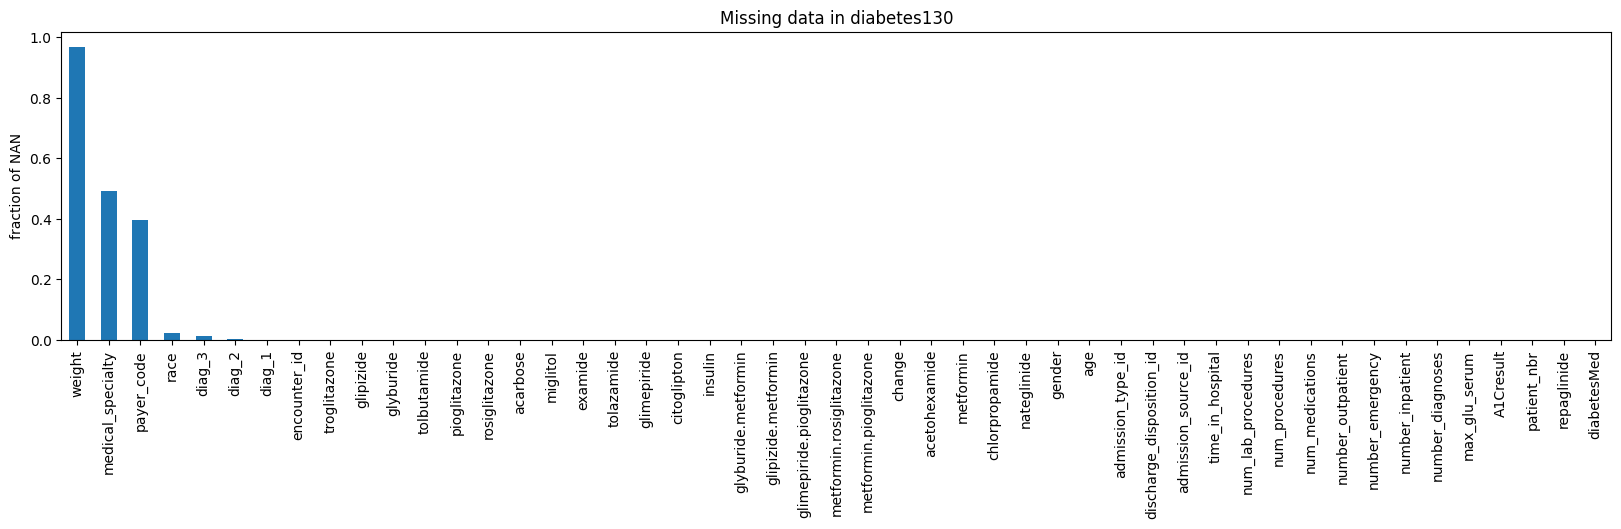

In [8]:
X_na.isnull().mean().sort_values(ascending=False).plot(kind='bar', figsize=(20, 4))
plt.title("Missing data in diabetes130")
plt.ylabel("fraction of NAN")
plt.show()

`weight` is missing for 97% of patients, `medical_specialty` for 49%, and `payer_code` for 40% — these are effectively unusable as continuous features without heavy imputation or being dropped. `race` and the 3 diagnosis codes have comparatively little missing data.

## Constant features

In [9]:
sel = DropConstantFeatures().fit(X_na.fillna('Missing'))
sel.features_to_drop_

['examide', 'citoglipton']

`examide` and `citoglipton` take a single value across all 101,766 encounters, so they carry no information.

## Categorical variables

What the categories actually contain — low-cardinality variables get their full set of values, the high-cardinality diagnosis codes get a value count instead.

In [10]:
low_card_vars = [v for v in cat_vars if X[v].nunique() <= 20]

for var in low_card_vars:
    print(var)
    print(X[var].unique())
    print()

race
['Caucasian', 'AfricanAmerican', '?', 'Other', 'Asian', 'Hispanic']
Categories (6, str): ['?', 'AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other']

gender
['Female', 'Male', 'Unknown/Invalid']
Categories (3, str): ['Female', 'Male', 'Unknown/Invalid']

age
['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
Categories (10, str): ['[0-10)', '[10-20)', '[20-30)', '[30-40)', ..., '[60-70)', '[70-80)', '[80-90)', '[90-100)']

weight
['?', '[75-100)', '[50-75)', '[0-25)', '[100-125)', '[25-50)', '[125-150)', '[175-200)', '[150-175)', '>200']
Categories (10, str): ['>200', '?', '[0-25)', '[100-125)', ..., '[175-200)', '[25-50)', '[50-75)', '[75-100)']

payer_code
['?', 'MC', 'MD', 'HM', 'UN', ..., 'WC', 'OT', 'OG', 'MP', 'FR']
Length: 18
Categories (18, str): ['?', 'BC', 'CH', 'CM', ..., 'WC', 'OG', 'MP', 'FR']

max_glu_serum
['None', '>300', 'Norm', '>200']
Categories (4, str): ['>200', '>300', 'None', 'Norm']

A1Cres

`gender` has an `Unknown/Invalid` category besides `Male`/`Female`. `age` and `weight` are already binned into 10-year / 25-unit ranges rather than continuous.

In [11]:
high_card_vars = [v for v in cat_vars if v not in low_card_vars]
high_card_vars

['medical_specialty', 'diag_1', 'diag_2', 'diag_3']

In [12]:
for var in high_card_vars:
    print(var, '-', X[var].nunique(), 'unique values')

    print(X[var].value_counts().head(10))
    print()

medical_specialty - 73 unique values
medical_specialty
?                             49949
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64

diag_1 - 717 unique values
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

diag_2 - 749 unique values
diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

diag_3 - 790 unique values
diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64



`diag_1`, `diag_2` and `diag_3` are ICD-9 diagnosis codes with 700+ levels each, mostly numeric but with some alphanumeric codes (e.g. `V27`, `E854`) mixed in.

In [13]:
diag_cols = ["diag_1", "diag_2", "diag_3"]

for col in diag_cols:
    non_numeric_count = pd.to_numeric(X[col], errors='coerce').isnull().sum()
    print(f"{col}: {non_numeric_count / len(X):.2%} non-numeric codes")

diag_1: 1.64% non-numeric codes
diag_2: 2.84% non-numeric codes
diag_3: 6.37% non-numeric codes


## Distributions of continuous variables

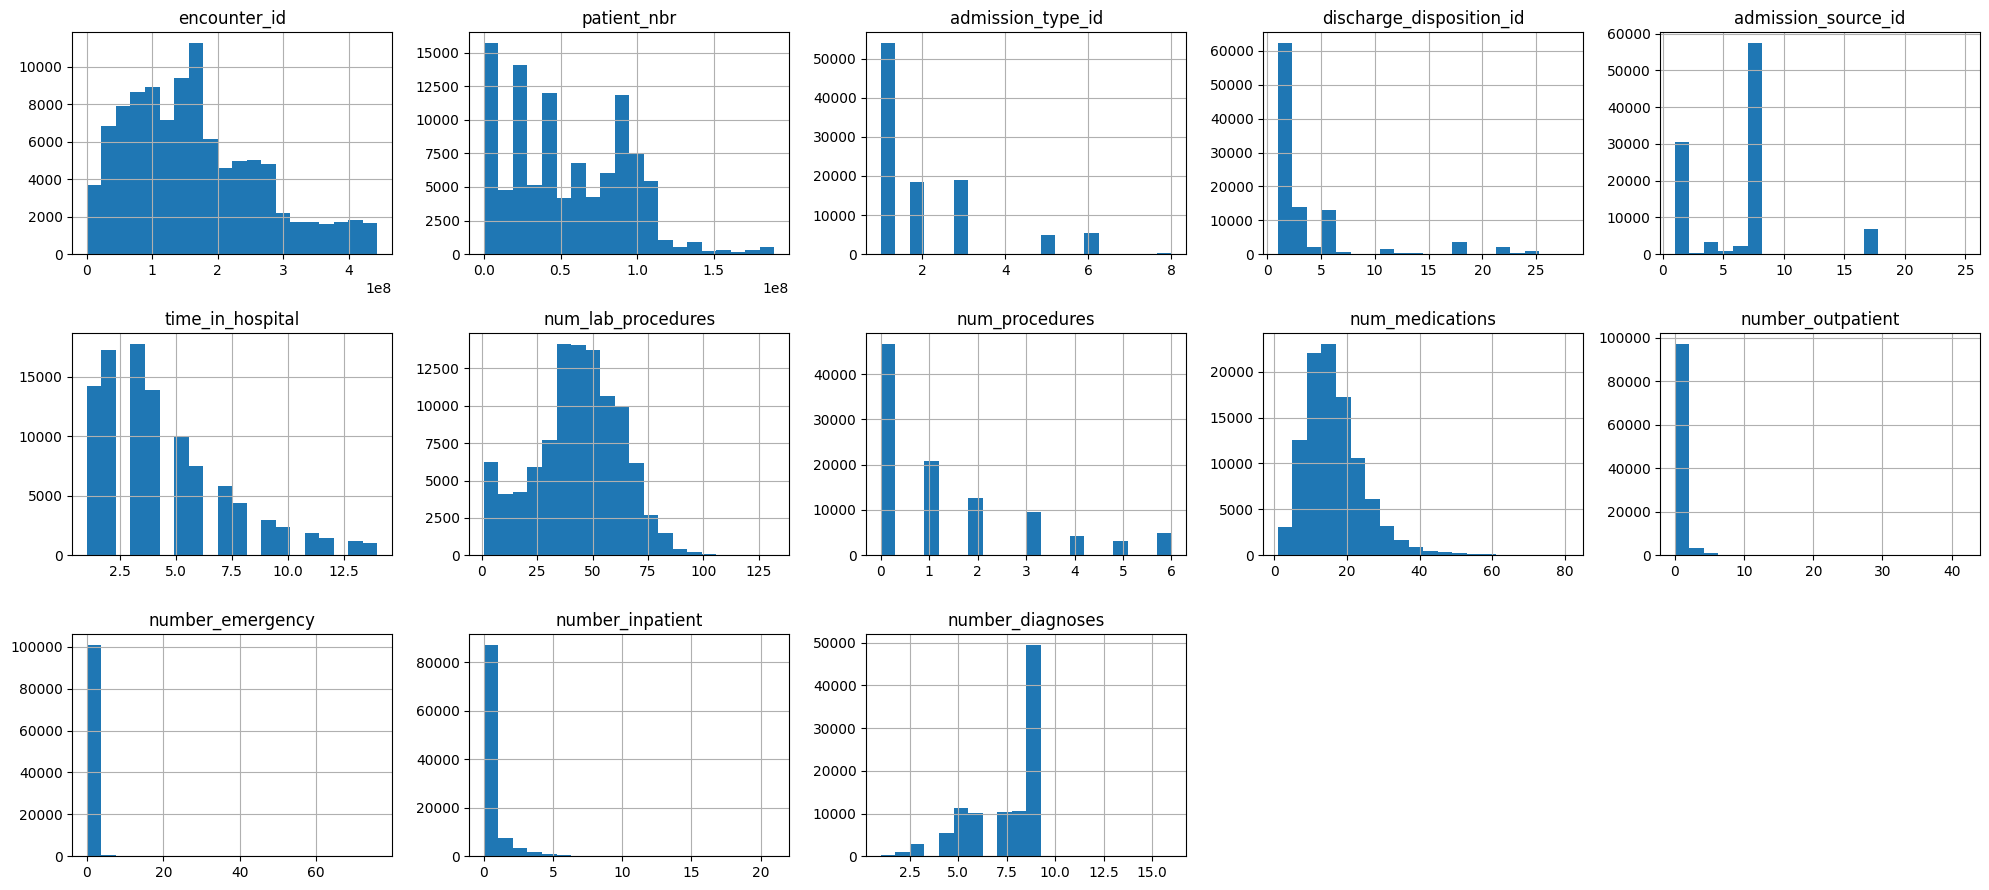

In [14]:
num_vars = X.select_dtypes(include="number").columns

n_cols = 5
n_rows = int(np.ceil(len(num_vars) / n_cols))

X[num_vars].hist(bins=20, figsize=(4 * n_cols, 3 * n_rows), layout=(n_rows, n_cols))
plt.tight_layout()
plt.show()

`encounter_id` and `patient_nbr` are identifiers, not features — their "distributions" are meaningless and should be dropped before modelling. `number_outpatient`, `number_emergency` and `number_inpatient` are heavily right-skewed, with most patients at 0 prior visits.

## Target class balance

In [15]:
y.value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [16]:
counts = y.value_counts()
majority, minority = counts.max(), counts.min()
print(f"Imbalance ratio (majority:minority) = {majority / minority:.1f}:1")

Imbalance ratio (majority:minority) = 4.8:1


`readmitted` has 3 classes. `NO` (54,864) is the largest, `<30` (11,357) the smallest — about 4.8:1 against the `<30` class, which is usually the one of clinical interest (early readmission).

## Summary

- 101,766 encounters, 49 columns (`encounter_id`, `patient_nbr` are identifiers, not features).
- 36 of 47 remaining variables are categorical.
- Missing values are encoded as `"?"`, not `NaN`: `weight` (97%), `medical_specialty` (49%) and `payer_code` (40%) are missing for most patients; `race` and the diagnosis codes have small amounts of missing data.
- `examide` and `citoglipton` are constant and can be dropped.
- `diag_1`/`diag_2`/`diag_3` are high-cardinality ICD-9 codes, mostly numeric with a minority of alphanumeric codes — they'll need grouping or encoding before modelling.
- The numeric visit-count features (`number_outpatient`, `number_emergency`, `number_inpatient`) are heavily right-skewed.
- The target `readmitted` is a 3-class imbalance problem: `NO` / `>30` / `<30`, with the clinically interesting `<30` class outnumbered roughly 4.8:1 by the majority class.